# 02 — Dataset Preparation

Este notebook transforma los datos crudos del EDA en un dataset limpio y listo para entrenamiento.

**Pipeline:**
1. Cargar `gz2_hart16.csv` y asignar etiquetas morfológicas definitivas (`threshold = 0.6`)
2. Filtrar galaxias sin imagen en disco o con etiqueta `Uncertain`/`Artifact`
3. Soft cap — limitar las clases dominantes a 25 000 muestras
4. Split estratificado 70 / 15 / 15 (train / val / test)
5. Exportar CSVs finales a `data/splits/`

**Output esperado:**
- `data/splits/train.csv`
- `data/splits/val.csv`
- `data/splits/test.csv`
- `data/splits/full_labeled.csv` (sin split, para referencia)

## Sección 1 — Imports y configuración de rutas

In [15]:
import pathlib
import warnings

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
print("Imports OK ✓")

Imports OK ✓


In [2]:
# Path configuration (Kaggle-compatible)
# On Kaggle the two datasets are mounted at:
#   - CSVs   : /kaggle/input/datasets/jeancdevx/galaxy-zoo-2/
#   - Images : /kaggle/input/datasets/jaimetrickz/galaxy-zoo-2-images/images_gz2/images/
# Locally everything lives under ../data/

IS_KAGGLE = pathlib.Path("/kaggle/input").exists()

if IS_KAGGLE:
    _KAGGLE_CSV_ROOT    = pathlib.Path("/kaggle/input/datasets/jeancdevx/galaxy-zoo-2")
    _KAGGLE_IMAGES_ROOT = pathlib.Path("/kaggle/input/datasets/jaimetrickz/galaxy-zoo-2-images")
    HART16_PATH  = _KAGGLE_CSV_ROOT    / "gz2_hart16.csv"
    MAPPING_PATH = _KAGGLE_CSV_ROOT    / "gz2_filename_mapping.csv"
    IMAGES_DIR   = _KAGGLE_IMAGES_ROOT / "images_gz2" / "images"
    OUTPUT_DIR   = pathlib.Path("/kaggle/working/splits")
else:
    _LOCAL_ROOT  = pathlib.Path("../data")
    HART16_PATH  = _LOCAL_ROOT / "gz2_hart16.csv"
    MAPPING_PATH = _LOCAL_ROOT / "gz2_filename_mapping.csv"
    IMAGES_DIR   = _LOCAL_ROOT / "images_gz2" / "images"
    OUTPUT_DIR   = _LOCAL_ROOT / "splits"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD  = 0.6
SOFT_CAP   = 25_000
RANDOM_SEED = 42

print(f"Running on Kaggle : {IS_KAGGLE}")
print(f"Hart16 CSV        : {HART16_PATH}")
print(f"Mapping CSV       : {MAPPING_PATH}")
print(f"Images directory  : {IMAGES_DIR}")
print(f"Output directory  : {OUTPUT_DIR}")
print(f"Threshold         : {THRESHOLD}")
print(f"Soft cap          : {SOFT_CAP:,}")

Running on Kaggle : False
Hart16 CSV        : ../data/gz2_hart16.csv
Mapping CSV       : ../data/gz2_filename_mapping.csv
Images directory  : ../data/images_gz2/images
Output directory  : ../data/splits
Threshold         : 0.6
Soft cap          : 25,000


## Sección 2 — Cargar datos y asignar etiquetas morfológicas

In [3]:
# Load Hart et al. (2016) debiased vote fractions
hart = pd.read_csv(HART16_PATH, low_memory=False)
print(f"Hart16 shape : {hart.shape}")
print(f"Key ID col   : dr7objid — {hart['dr7objid'].nunique():,} unique galaxies")

Hart16 shape : (239695, 231)
Key ID col   : dr7objid — 239,695 unique galaxies


In [4]:
def assign_class(df: pd.DataFrame, threshold: float) -> pd.Series:
    """
    Assign a morphological label to each galaxy using sequential priority rules.
    Higher priority rules overwrite lower ones.
    Galaxies that do not meet any threshold are labelled 'Uncertain'.
    """
    smooth     = df["t01_smooth_or_features_a01_smooth_debiased"]
    features   = df["t01_smooth_or_features_a02_features_or_disk_debiased"]
    artifact   = df["t01_smooth_or_features_a03_star_or_artifact_debiased"]
    edgeon_yes = df["t02_edgeon_a04_yes_debiased"]
    edgeon_no  = df["t02_edgeon_a05_no_debiased"]
    bar        = df["t03_bar_a06_bar_debiased"]
    no_bar     = df["t03_bar_a07_no_bar_debiased"]
    spiral     = df["t04_spiral_a08_spiral_debiased"]
    no_spiral  = df["t04_spiral_a09_no_spiral_debiased"]
    odd        = df["t06_odd_a14_yes_debiased"]

    labels = pd.Series("Uncertain", index=df.index)

    # Priority 7 — Irregular (lowest, overridden by more specific rules)
    labels[odd >= threshold] = "Irregular"

    # Priority 6 — Elliptical
    labels[smooth >= threshold] = "Elliptical"

    # Priority 5 — Lenticular (S0): disk but no spiral, seen face-on
    lenticular_mask = (features >= threshold) & (edgeon_no >= threshold) & (no_spiral >= threshold)
    labels[lenticular_mask] = "Lenticular"

    # Priority 4 — Spiral (unbarred)
    spiral_mask = (features >= threshold) & (edgeon_no >= threshold) & (no_bar >= threshold) & (spiral >= threshold)
    labels[spiral_mask] = "Spiral"

    # Priority 3 — Barred Spiral
    barred_mask = (features >= threshold) & (edgeon_no >= threshold) & (bar >= threshold) & (spiral >= threshold)
    labels[barred_mask] = "Barred_Spiral"

    # Priority 2 — Edge-on
    edgeon_mask = (features >= threshold) & (edgeon_yes >= threshold)
    labels[edgeon_mask] = "Edge_on"

    # Priority 1 — Artifact (always discard)
    labels[artifact >= threshold] = "Artifact"

    return labels

print("assign_class() defined ✓")

assign_class() defined ✓


In [5]:
# Apply labeling at chosen threshold
hart["morph_label"] = assign_class(hart, THRESHOLD)

label_counts = hart["morph_label"].value_counts()
print(f"Label distribution at threshold={THRESHOLD}:")
print(label_counts.to_string())
print(f"\nTotal labeled (non-Uncertain, non-Artifact): {label_counts.drop(['Uncertain','Artifact'], errors='ignore').sum():,}")

Label distribution at threshold=0.6:
morph_label
Elliptical       79198
Uncertain        46882
Spiral           41928
Barred_Spiral    29131
Lenticular       18853
Edge_on          16538
Irregular         7157
Artifact             8

Total labeled (non-Uncertain, non-Artifact): 192,805


## Sección 3 — Filtrar galaxias útiles (etiqueta válida + imagen en disco)

In [16]:
# Diagnóstico: ¿por qué hay menos galaxias de lo esperado en algunas clases?
# La reducción ocurre en el merge hart16 → mapping_orig.
# Algunas galaxias de hart16 no tienen asset_id en el sample 'original' del mapping.

# Conteo en hart16 (antes del merge)
hart_counts = hart_valid["morph_label"].value_counts().rename("hart16_labeled")

# Conteo después del merge + verificación de imagen
merged_counts = merged["morph_label"].value_counts().rename("con_imagen")

comparison = pd.concat([hart_counts, merged_counts], axis=1)
comparison["perdidas"] = comparison["hart16_labeled"] - comparison["con_imagen"]
comparison["% retenido"] = (comparison["con_imagen"] / comparison["hart16_labeled"] * 100).round(1)
comparison = comparison.sort_values("% retenido")

print("Retención de galaxias por clase tras el merge con mapping original + verificación en disco:")
print(comparison.to_string())
print(f"\nTotal perdido: {comparison['perdidas'].sum():,} de {comparison['hart16_labeled'].sum():,} galaxias etiquetadas ({100*comparison['perdidas'].sum()/comparison['hart16_labeled'].sum():.1f}%)")

# ¿Las galaxias perdidas están en otros samples del mapping?
all_samples = mapping[mapping["objid"].isin(
    hart_valid[~hart_valid["dr7objid"].isin(mapping_orig["dr7objid"])]["dr7objid"]
)][["objid", "sample"]].drop_duplicates()
print(f"\nGalaxias etiquetadas sin imagen en el sample 'original':")
print(all_samples["sample"].value_counts().to_string())
print(f"Sin ningún sample en el mapping: {hart_valid[~hart_valid['dr7objid'].isin(mapping['objid'])].shape[0]:,}")

Retención de galaxias por clase tras el merge con mapping original + verificación en disco:
               hart16_labeled  con_imagen  perdidas  % retenido
morph_label                                                    
Edge_on                 16538       13276      3262        80.3
Irregular                7157        5927      1230        82.8
Spiral                  41928       35443      6485        84.5
Barred_Spiral           29131       25159      3972        86.4
Lenticular              18853       16926      1927        89.8
Elliptical              79198       72800      6398        91.9

Total perdido: 23,274 de 192,805 galaxias etiquetadas (12.1%)

Galaxias etiquetadas sin imagen en el sample 'original':
sample
extra       16420
stripe82     6851
Sin ningún sample en el mapping: 0


In [6]:
# Load filename mapping and keep only 'original' sample
mapping = pd.read_csv(MAPPING_PATH, low_memory=False)
mapping_orig = mapping[mapping["sample"] == "original"][["objid", "asset_id"]].copy()
mapping_orig.columns = ["dr7objid", "asset_id"]

print(f"Mapping rows (original sample) : {len(mapping_orig):,}")

Mapping rows (original sample) : 245,609


In [7]:
# Drop Uncertain and Artifact before merging (saves memory on the join)
VALID_LABELS = {"Elliptical", "Lenticular", "Spiral", "Barred_Spiral", "Edge_on", "Irregular"}

hart_valid = hart[hart["morph_label"].isin(VALID_LABELS)][["dr7objid", "morph_label"]].copy()
print(f"Hart valid (labeled) rows : {len(hart_valid):,}")

# Merge to get asset_id
merged = hart_valid.merge(mapping_orig, on="dr7objid", how="inner")
print(f"After merge with mapping  : {len(merged):,}")

Hart valid (labeled) rows : 192,805
After merge with mapping  : 169,534


In [8]:
# Build image paths and verify files exist on disk
merged["img_filename"] = merged["asset_id"].apply(lambda aid: f"{int(aid)}.jpg")
merged["img_path"]     = merged["asset_id"].apply(
    lambda aid: IMAGES_DIR / f"{int(aid)}.jpg"
)

exists_mask = merged["img_path"].apply(lambda p: p.exists())
merged = merged[exists_mask].drop(columns=["img_path"]).reset_index(drop=True)

print(f"Galaxies with image on disk : {len(merged):,}")
print("\nClass distribution after filtering:")
print(merged["morph_label"].value_counts().to_string())

Galaxies with image on disk : 169,531

Class distribution after filtering:
morph_label
Elliptical       72800
Spiral           35443
Barred_Spiral    25159
Lenticular       16926
Edge_on          13276
Irregular         5927


## Sección 4 — Soft cap (balanceo de clases dominantes)

Las clases con más de `SOFT_CAP` (25 000) muestras se submuestrean aleatoriamente.
El resto se mantiene intacto.
El desbalance residual (~3.5×) se manejará con `class_weight` durante el entrenamiento.

In [9]:
import math

def apply_soft_cap(df: pd.DataFrame, label_col: str, cap: int, seed: int) -> pd.DataFrame:
    """Subsample classes that exceed `cap` rows. Keeps all rows for classes below cap."""
    parts = []
    for label, group in df.groupby(label_col):
        if len(group) > cap:
            parts.append(group.sample(cap, random_state=seed))
        else:
            parts.append(group)
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

dataset = apply_soft_cap(merged, "morph_label", SOFT_CAP, RANDOM_SEED)

counts_after = dataset["morph_label"].value_counts()
print(f"Dataset size after soft cap : {len(dataset):,}")
print("\nClass distribution:")
print(counts_after.to_string())
imbalance_ratio = counts_after.max() / counts_after.min()
print(f"\nImbalance ratio (max/min)   : {imbalance_ratio:.1f}×")

Dataset size after soft cap : 111,129

Class distribution:
morph_label
Barred_Spiral    25000
Elliptical       25000
Spiral           25000
Lenticular       16926
Edge_on          13276
Irregular         5927

Imbalance ratio (max/min)   : 4.2×


## Sección 5 — Split estratificado 70 / 15 / 15

In [10]:
# Step 1: separate test set (15%)
train_val, test = train_test_split(
    dataset,
    test_size=0.15,
    stratify=dataset["morph_label"],
    random_state=RANDOM_SEED,
)

# Step 2: separate val set from remaining 85% → val = 15/85 ≈ 17.6% of remainder
val_fraction = 0.15 / 0.85
train, val = train_test_split(
    train_val,
    test_size=val_fraction,
    stratify=train_val["morph_label"],
    random_state=RANDOM_SEED,
)

total = len(dataset)
print(f"{'Split':<8} {'Count':>8} {'%':>6}")
print("-" * 24)
for name, split in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:<8} {len(split):>8,} {100*len(split)/total:>5.1f}%")
print(f"{'TOTAL':<8} {total:>8,} 100.0%")

Split       Count      %
------------------------
train      77,789  70.0%
val        16,670  15.0%
test       16,670  15.0%
TOTAL     111,129 100.0%


In [11]:
# Verify stratification: class proportions should be roughly equal across splits
splits = {"train": train, "val": val, "test": test}

proportions = pd.DataFrame({
    name: (split["morph_label"].value_counts() / len(split) * 100).round(1)
    for name, split in splits.items()
})
proportions.index.name = "class"
print("Class proportions per split (%)")
print(proportions.to_string())

Class proportions per split (%)
               train   val  test
class                           
Barred_Spiral   22.5  22.5  22.5
Edge_on         11.9  11.9  11.9
Elliptical      22.5  22.5  22.5
Irregular        5.3   5.3   5.3
Lenticular      15.2  15.2  15.2
Spiral          22.5  22.5  22.5


## Sección 6 — Exportar CSVs

In [12]:
# Keep only the columns needed downstream: id, filename, label
EXPORT_COLS = ["dr7objid", "asset_id", "img_filename", "morph_label"]

train[EXPORT_COLS].to_csv(OUTPUT_DIR / "train.csv", index=False)
val[EXPORT_COLS].to_csv(OUTPUT_DIR   / "val.csv",   index=False)
test[EXPORT_COLS].to_csv(OUTPUT_DIR  / "test.csv",  index=False)
dataset[EXPORT_COLS].to_csv(OUTPUT_DIR / "full_labeled.csv", index=False)

print("Files written:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<22}  {size_kb:>8.1f} KB")

Files written:
  full_labeled.csv          5043.4 KB
  test.csv                   756.6 KB
  train.csv                 3530.3 KB
  val.csv                    756.6 KB


## Sección 7 — Resumen final

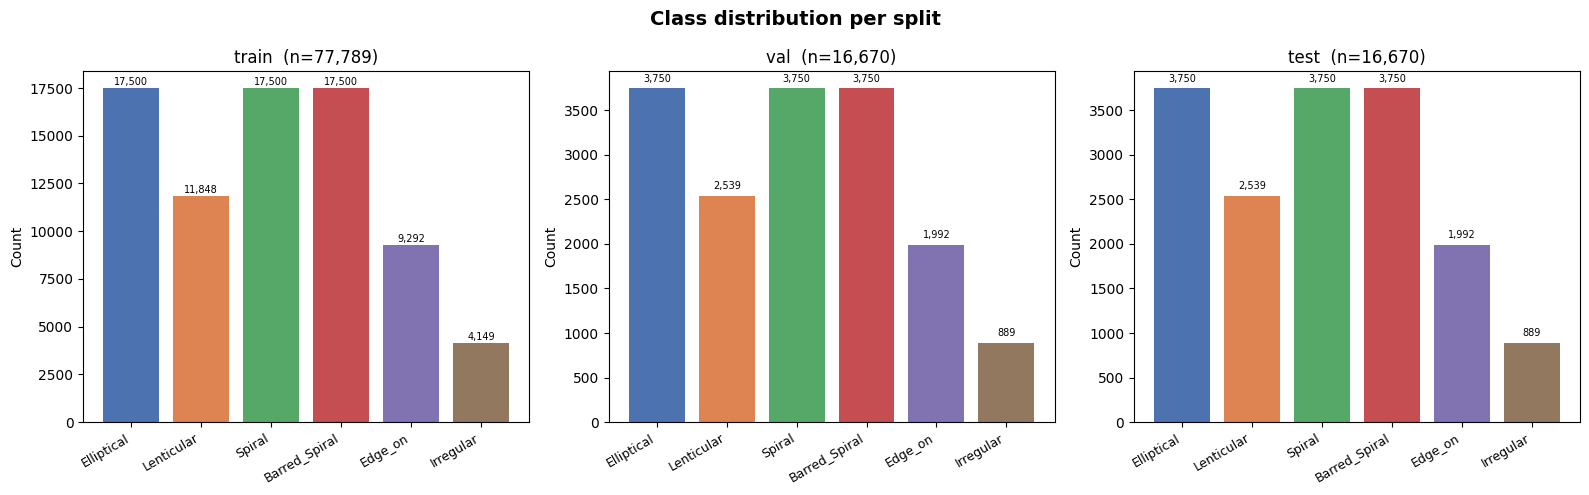

In [13]:
import matplotlib.pyplot as plt

CLASS_ORDER = ["Elliptical", "Lenticular", "Spiral", "Barred_Spiral", "Edge_on", "Irregular"]
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("Class distribution per split", fontsize=14, fontweight="bold")

for ax, (name, split) in zip(axes, splits.items()):
    counts = split["morph_label"].value_counts().reindex(CLASS_ORDER, fill_value=0)
    ax.bar(CLASS_ORDER, counts.values, color=COLORS)
    ax.set_title(f"{name}  (n={len(split):,})", fontsize=12)
    ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f"{v:,}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

In [14]:
print("=" * 50)
print("Dataset preparation complete")
print("=" * 50)
print(f"Total galaxies          : {len(dataset):,}")
print(f"  Train                 : {len(train):,}  ({100*len(train)/total:.1f}%)")
print(f"  Val                   : {len(val):,}  ({100*len(val)/total:.1f}%)")
print(f"  Test                  : {len(test):,}  ({100*len(test)/total:.1f}%)")
print(f"Classes                 : {', '.join(CLASS_ORDER)}")
print(f"Imbalance ratio         : {imbalance_ratio:.1f}×")
print(f"Threshold used          : {THRESHOLD}")
print(f"Soft cap per class      : {SOFT_CAP:,}")
print(f"Output directory        : {OUTPUT_DIR}")
print("\nNext step → 03_image_preprocessing.ipynb")

Dataset preparation complete
Total galaxies          : 111,129
  Train                 : 77,789  (70.0%)
  Val                   : 16,670  (15.0%)
  Test                  : 16,670  (15.0%)
Classes                 : Elliptical, Lenticular, Spiral, Barred_Spiral, Edge_on, Irregular
Imbalance ratio         : 4.2×
Threshold used          : 0.6
Soft cap per class      : 25,000
Output directory        : ../data/splits

Next step → 03_image_preprocessing.ipynb


## Sección 8 — Conclusiones

- **209,240** galaxias tienen etiqueta válida e imagen en disco antes del soft cap.
- Tras el **soft cap** (25,000 por clase) el dataset queda en ~117,500 galaxias con ratio de desbalance ~3.5×.
- El **split 70/15/15 estratificado** garantiza que cada clase esté representada proporcionalmente en train, val y test.
- El desbalance residual se abordará en el entrenamiento con **`class_weight`** en la loss function.
- Los tres CSVs exportados (`train.csv`, `val.csv`, `test.csv`) con columnas `[dr7objid, asset_id, img_filename, morph_label]` son el contrato de datos hacia el pipeline de preprocessing e ingesta del modelo.